## Deep Learning


## Табличная модель: риск недовольства клиента

Это вторая часть проекта после EDA. Здесь я строю табличную нейросеть (MLP), которая по информации о заказе предсказывает риск того, что клиент останется недоволен.

Из EDA мы поняли, что retention-таргет (не вернулся за 90 дней) почти у всех клиентов равен 1, поэтому он слобо информативен для нас . Поэтому основным таргетом для табличной модели берем risk_dissatisfaction, то есть плохой отзыв с оценкой <= 2.

Бизнес-смысл: если для заказа модель показывает высокий риск недовольства, поддержка может заранее подключиться к клиенту, а дальше этот риск идет в offer engine вместе с текстовой моделью.

In [1]:
!pip install -q torchinfo wandb

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

from torchinfo import summary
import wandb

%matplotlib inline

In [3]:
device = torch.device("cuda")

In [4]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(42)

## Постановка табличной задачи

Здесь я беру таблицу order_level_dataset.csv, где одна строка это один заказ,
таргет risk_dissatisfaction равен 1, если review_score <= 2

Важный момент про утечку таргета. Признаки review_score, has_text и comment_len берутся из самого отзыва, то есть становятся известны уже после того, как клиент оставил отзыв. Если их оставить, модель будет читерить и смотреть фактически на ответ. Поэтому я их выкидываю и предсказываю риск недовольства только по информации о заказе, доставке, оплате, географии и категории

In [5]:
df = pd.read_csv('order_level_dataset.csv')
df.shape

(98673, 30)

In [6]:
df

,order_id,customer_unique_id,customer_state,customer_city,order_purchase_timestamp,order_status,order_total,items_price,freight_value,freight_share,...,delay_days,is_late,has_text,comment_len,review_score,risk_dissatisfaction,not_delivered,multiple_sellers,high_installments,expensive_order
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,2017-10-02 10:56:33,delivered,38.71,29.99,8.72,0.225265,...,-8.0,0,1.0,170.0,4.0,0,0,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,barreiras,2018-07-24 20:41:37,delivered,141.46,118.70,22.76,0.160894,...,-6.0,0,1.0,20.0,4.0,0,0,0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,2018-08-08 08:38:49,delivered,179.12,159.90,19.22,0.107302,...,-18.0,0,0.0,0.0,5.0,0,0,0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,2017-11-18 19:28:06,delivered,72.20,45.00,27.20,0.376731,...,-13.0,0,1.0,105.0,5.0,0,0,0,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,2018-02-13 21:18:39,delivered,28.62,19.90,8.72,0.304682,...,-10.0,0,0.0,0.0,5.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98668,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,SP,sao jose dos campos,2017-03-09 09:54:05,delivered,85.08,72.00,13.08,0.153738,...,-11.0,0,0.0,0.0,5.0,0,0,0,0,0
98669,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,SP,praia grande,2018-02-06 12:58:58,delivered,195.00,174.90,20.10,0.103077,...,-2.0,0,1.0,44.0,4.0,0,0,0,0,0
98670,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,BA,nova vicosa,2017-08-27 14:46:43,delivered,271.01,205.99,65.02,0.239917,...,-6.0,0,1.0,28.0,5.0,0,0,0,0,1
98671,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,RJ,japuiba,2018-01-08 21:28:27,delivered,441.16,359.98,81.18,0.184015,...,-21.0,0,1.0,53.0,2.0,1,0,0,0,1


In [7]:
df['risk_dissatisfaction'].value_counts()

,count
risk_dissatisfaction,
0,84224
1,14449


Text(0, 0.5, 'количество заказов')

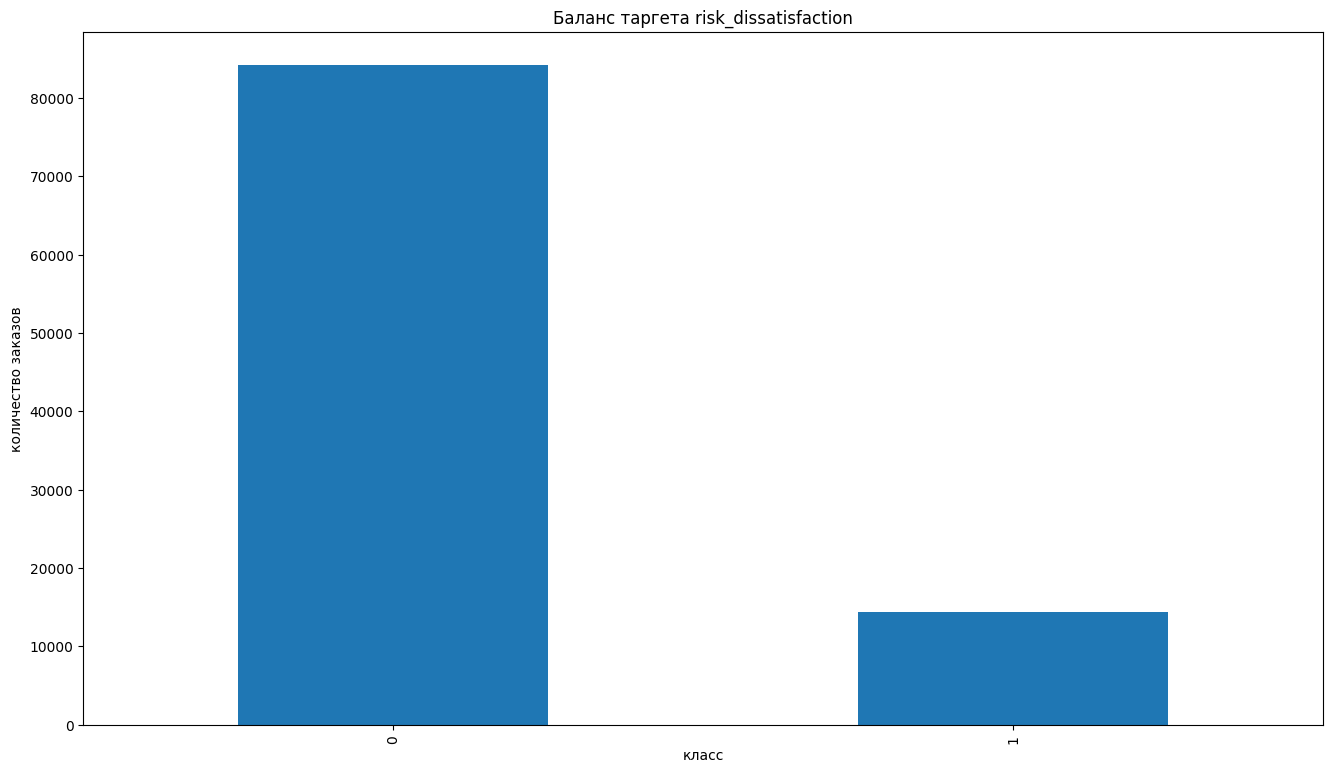

In [8]:
# баланс классов
balance = df['risk_dissatisfaction'].mean() * 100

plt.figure(figsize = (16, 9))
df['risk_dissatisfaction'].value_counts().plot(kind = 'bar')
plt.title('Баланс таргета risk_dissatisfaction')
plt.xlabel('класс')
plt.ylabel('количество заказов')

In [9]:
print('Доля рискованных заказов', round(balance, 2), '%')

Доля рискованных заказов 14.64 %


Видим что классы несбалансированы, рискованных заказов примерно 15%. Это важно держать в голове - accuracy тут будет обманчивой метрикой, поэтому дальше смотрю в первую очередь на ROC-AUC, recall и F1 по классу риска. Для бизнеса важнее поймать недовольного клиента чем лишний раз ошибиться на спокойном.


## Feature engineering

Делю признаки на числовые и категориальные.

Числовые: стоимость заказа, доставка, оплата, количество товаров и продавцов, дни доставки и задержки, плюс бинарные флаги;
Категориальные: штат клиента, основная категория, основной способ оплаты и статус заказа.

Категориальные признаки потом пойдут в нейросеть через эмбеддинг слои, поэтому пока перевожу их в числовые коды.


In [10]:
leak_cols = ['review_score', 'has_text', 'comment_len', 'risk_dissatisfaction']
id_cols = ['order_id', 'customer_unique_id', 'customer_city', 'order_purchase_timestamp']

num_cols = [
    'order_total', 'items_price', 'freight_value', 'freight_share', 'payment_value',
    'payment_installments', 'payment_type_count', 'order_item_count', 'unique_products',
    'unique_sellers', 'delivery_days', 'estimated_delivery_days', 'delay_days',
    'is_late', 'not_delivered', 'multiple_sellers', 'high_installments', 'expensive_order'
]
cat_cols = ['customer_state', 'main_category', 'main_payment_type', 'order_status']


пропуски в днях доставки у недоставленных заказов, заполняю медианой

In [11]:
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
df[num_cols].isna().sum().sum()

np.int64(0)

In [12]:
df['main_category'] = df['main_category'].fillna('unknown')
df['main_payment_type'] = df['main_payment_type'].fillna('unknown')

top_cat = df['main_category'].value_counts().head(30).index
df['main_category'] = np.where(df['main_category'].isin(top_cat), df['main_category'], 'other')

df['main_category'].nunique()

31

категориальные в числовые коды для эмбеддинга

In [13]:
cardinalities = []
for c in cat_cols:
    df[c] = df[c].astype('category')
    df[c + '_code'] = df[c].cat.codes
    cardinalities.append(df[c + '_code'].max() + 1)

cat_code_cols = [c + '_code' for c in cat_cols]
cardinalities

[np.int8(27), np.int8(31), np.int8(6), np.int8(8)]

In [14]:
X_num = df[num_cols].values.astype('float32')
X_cat = df[cat_code_cols].values.astype('int64')
y = df['risk_dissatisfaction'].values.astype('float32')

print('X_num', X_num.shape)
print('X_cat', X_cat.shape)
print('y', y.shape)

X_num (98673, 18)
X_cat (98673, 4)
y (98673,)


In [15]:
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size = 0.2, random_state = 42, stratify = y)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num[train_idx])
X_num_test = scaler.transform(X_num[test_idx])

X_cat_train, X_cat_test = X_cat[train_idx], X_cat[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('train', X_num_train.shape, 'test', X_num_test.shape)
print('доля рискованных в  train', y_train.mean(), 'test', y_test.mean())

train (78938, 18) test (19735, 18)
доля рискованных в  train 0.14643137 test 0.14644033


## Baseline

Перед нейронкой построю простые модели чтобы было с чем сравнивать
Беру три бэйзлайна: DummyClassifier — самый тупой, линейная модель,
RandomForest.
Ещё склею числовые и категориальные признаки в матрицу через pnehot


In [16]:
X_cat_ohe = pd.get_dummies(df[cat_cols], columns = cat_cols).values

X_base_train = np.hstack([scaler.transform(X_num[train_idx]), X_cat_ohe[train_idx]])
X_base_test = np.hstack([scaler.transform(X_num[test_idx]), X_cat_ohe[test_idx]])

X_base_train.shape

(78938, 90)

In [17]:
def evaluate(y_true, y_proba, name):
    y_pred = (y_proba >= 0.5).astype(int)
    res = {
        'model': name,
        'roc_auc': roc_auc_score(y_true, y_proba),
        'f1': f1_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred)
    }
    print(name)
    print('ROC-AUC', res['roc_auc'], 'F1', res['f1'],
          'recall', res['recall'], 'precision',res['precision'])
    return res

In [18]:
results = []

dummy = DummyClassifier(strategy = 'stratified', random_state = 42)
dummy.fit(X_base_train, y_train)
proba = dummy.predict_proba(X_base_test)[:, 1]
results.append(evaluate(y_test, proba, 'Dummy'))

Dummy
ROC-AUC 0.5040404522816931 F1 0.15331372209724867 recall 0.1532871972318339 precision 0.15334025614399446


In [19]:
logreg = LogisticRegression(max_iter = 1000, class_weight = 'balanced') #классы несбалансированы
logreg.fit(X_base_train, y_train)
proba = logreg.predict_proba(X_base_test)[:, 1]
results.append(evaluate(y_test, proba, 'LogReg'))

LogReg
ROC-AUC 0.7806400305656809 F1 0.5139591836734694 recall 0.5446366782006921 precision 0.4865533230293663


In [20]:
rf = RandomForestClassifier(n_estimators = 300, class_weight = 'balanced', random_state = 42, n_jobs = -1)
rf.fit(X_base_train, y_train)
proba = rf.predict_proba(X_base_test)[:, 1]
results.append(evaluate(y_test, proba, 'RandomForest'))

RandomForest
ROC-AUC 0.7715287975752871 F1 0.5138764547896151 recall 0.3972318339100346 precision 0.7275031685678074


In [21]:
baseline_table = pd.DataFrame(results)
baseline_table

,model,roc_auc,f1,recall,precision
0,Dummy,0.504040,0.153314,0.153287,0.153340
1,LogReg,0.780640,0.513959,0.544637,0.486553
2,RandomForest,0.771529,0.513876,0.397232,0.727503


Дальше эти бэйзлайны сравню с нейронками, главный ориентир по качеству это ROC-AUC и recall
